# 04 – Unsupervised Learning & Advanced Preprocessing (Preetham's Scikit-learn Mastery Series)

Welcome to **Part 4** of the Scikit-Learn Mastery Series! In supervised learning, models are guided by target labels $y$. In **unsupervised learning**, we uncover hidden patterns, structures, groupings, and representations directly from feature matrix $X$ without explicit labels.

---

### 📌 What You Will Master in This Notebook:
1. **Clustering Algorithms**: K-Means, Agglomerative Hierarchical Clustering, and DBSCAN.
2. **Clustering Evaluation**: Elbow Method, Silhouette Analysis, ARI, NMI, Calinski-Harabasz, and Davies-Bouldin metrics.
3. **Dimensionality Reduction**: Principal Component Analysis (PCA), TruncatedSVD, and t-SNE manifold learning.
4. **Feature Selection Strategies**: Filter methods (`SelectKBest`), Wrapper methods (`RFE`), and Embedded L1 methods (`SelectFromModel`).
5. **Missing Value Imputation**: `SimpleImputer`, `KNNImputer`, and `IterativeImputer` (MICE).
6. **Anomaly & Outlier Detection**: `IsolationForest` and `LocalOutlierFactor` (LOF).
7. **End-to-End Unsupervised Pipeline**: Integrating preprocessing, reduction, and clustering seamlessly.


In [2]:
# Setup, reproducible seeds, and dataset preparation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import datasets
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Set aesthetic plot styling
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 11

# Load Wine dataset (13 continuous features, 3 class labels for evaluation)
wine = datasets.load_wine()
X, y = wine.data, wine.target
feature_names = wine.feature_names
target_names = wine.target_names

# Standardize features (Mean = 0, Variance = 1) - CRITICAL for distance-based & variance-based methods
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Dataset Loaded: Wine Dataset")
print(f"Samples (n): {X.shape[0]} | Features (d): {X.shape[1]}")
print(f"Target Classes: {target_names}")
print(f"Scaled Mean (first 3): {X_scaled.mean(axis=0)[:3].round(4)}")
print(f"Scaled Std  (first 3): {X_scaled.std(axis=0)[:3].round(4)}")


Dataset Loaded: Wine Dataset
Samples (n): 178 | Features (d): 13
Target Classes: ['class_0' 'class_1' 'class_2']
Scaled Mean (first 3): [ 0.  0. -0.]
Scaled Std  (first 3): [1. 1. 1.]


---
## 1. K-Means Clustering

### 📐 Mathematical Formulation
K-Means partitions dataset $X = \{x_1, x_2, \dots, x_n\}$ into $k$ distinct, non-overlapping clusters $C = \{C_1, C_2, \dots, C_k\}$ by minimizing the **Within-Cluster Sum of Squares (WCSS)**, also known as **Inertia**:

$$J = \sum_{j=1}^{k} \sum_{x_i \in C_j} \|x_i - \mu_j\|^2$$

where $\mu_j$ is the centroid (mean vector) of cluster $C_j$:

$$\mu_j = \frac{1}{|C_j|} \sum_{x_i \in C_j} x_i$$

### 🔄 Algorithm Steps (Lloyd's Algorithm):
1. **Initialize**: Choose $k$ initial centroids $\mu_1, \dots, \mu_k$ (e.g., using `k-means++` smart seeding).
2. **Assign**: Assign each data point $x_i$ to the nearest centroid:
   $$C_j = \{ x_i : \|x_i - \mu_j\| \le \|x_i - \mu_l\|, \forall l \in \{1, \dots, k\} \}$$
3. **Update**: Recalculate each centroid as the mean of all points assigned to that cluster.
4. **Iterate**: Repeat Steps 2 & 3 until centroids stabilize (convergence) or max iterations are reached.


In [4]:
from sklearn.cluster import KMeans

# Fit K-Means with k=3 (matching the 3 wine classes)
kmeans = KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=42)
clusters_km = kmeans.fit_predict(X_scaled)

print("K-Means Results:")
print(f"Inertia (WCSS): {kmeans.inertia_:.2f}")
print(f"Number of iterations to converge: {kmeans.n_iter_}")
print(f"Cluster centroids shape: {kmeans.cluster_centers_.shape}")
print(f"Cluster sample distribution: {np.bincount(clusters_km)}")

# Compare random init vs k-means++ init
km_random = KMeans(n_clusters=3, init='random', n_init=1, random_state=42).fit(X_scaled)
km_pp = KMeans(n_clusters=3, init='k-means++', n_init=1, random_state=42).fit(X_scaled)
print(f"Inertia (1 pass random init): {km_random.inertia_:.2f}")
print(f"Inertia (1 pass k-means++): {km_pp.inertia_:.2f}")


K-Means Results:
Inertia (WCSS): 1277.93
Number of iterations to converge: 7
Cluster centroids shape: (3, 13)
Cluster sample distribution: [65 51 62]
Inertia (1 pass random init): 1282.46
Inertia (1 pass k-means++): 1277.93


---
## 2. Determining Optimal Clusters ($k$): Elbow Method & Silhouette Analysis

### 🎯 The Elbow Method
We plot Inertia $J(k)$ against cluster numbers $k \in [1, 10]$. Look for the "elbow point" where the rate of inertia decrease sharply levels off (diminishing returns).

### 📊 Silhouette Coefficient
For each sample $i$:
$$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$

- $a(i)$: Mean intra-cluster distance (distance from $i$ to all other points in its own cluster).
- $b(i)$: Mean nearest-cluster distance (distance from $i$ to points in the closest neighboring cluster).
- **Range**: $[-1, +1]$. High positive values indicate well-separated, dense clusters. Values near $0$ indicate overlapping clusters.


k =  2 | Silhouette Score: 0.2593
k =  3 | Silhouette Score: 0.2849
k =  4 | Silhouette Score: 0.2602
k =  5 | Silhouette Score: 0.2016
k =  6 | Silhouette Score: 0.2372
k =  7 | Silhouette Score: 0.2036
k =  8 | Silhouette Score: 0.1570
k =  9 | Silhouette Score: 0.1499
k = 10 | Silhouette Score: 0.1436


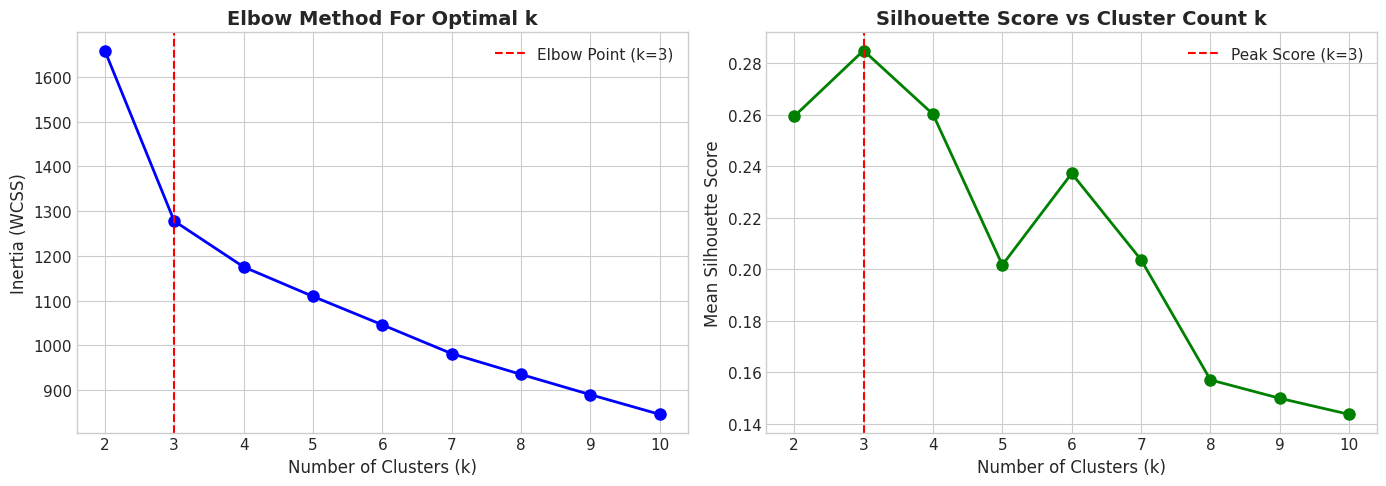

In [6]:
from sklearn.metrics import silhouette_score, silhouette_samples

inertias = []
silhouette_avg_scores = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42).fit(X_scaled)
    inertias.append(km.inertia_)
    score = silhouette_score(X_scaled, km.labels_)
    silhouette_avg_scores.append(score)

# Plotting Elbow and Silhouette curves side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Elbow curve
ax1.plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Clusters (k)', fontsize=12)
ax1.set_ylabel('Inertia (WCSS)', fontsize=12)
ax1.set_title('Elbow Method For Optimal k', fontsize=14, fontweight='bold')
ax1.axvline(x=3, color='r', linestyle='--', label='Elbow Point (k=3)')
ax1.legend()

# Silhouette curve
ax2.plot(k_range, silhouette_avg_scores, 'go-', linewidth=2, markersize=8)
ax2.set_xlabel('Number of Clusters (k)', fontsize=12)
ax2.set_ylabel('Mean Silhouette Score', fontsize=12)
ax2.set_title('Silhouette Score vs Cluster Count k', fontsize=14, fontweight='bold')
ax2.axvline(x=3, color='r', linestyle='--', label='Peak Score (k=3)')
ax2.legend()

plt.tight_layout()
plt.show()

for k, score in zip(k_range, silhouette_avg_scores):
    print(f"k = {k:2d} | Silhouette Score: {score:.4f}")


### 🖼️ Sample-Wise Silhouette Analysis Plot
A single mean silhouette score can hide cluster imbalances or poorly formed clusters. Visualizing per-sample silhouette widths for $k=2, 3, 4$ reveals cluster quality in detail.


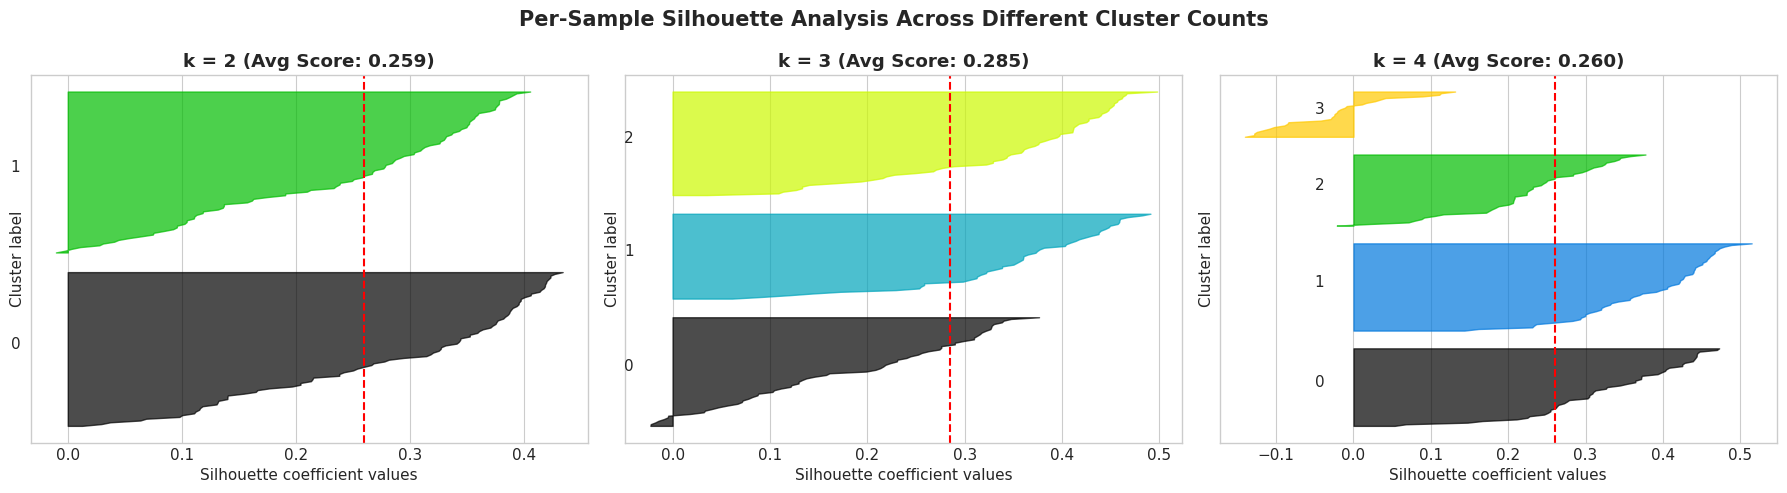

In [8]:
import matplotlib.cm as cm

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, k in enumerate([2, 3, 4]):
    ax = axes[idx]
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    cluster_labels = km.fit_predict(X_scaled)
    sil_avg = silhouette_score(X_scaled, cluster_labels)
    sample_sil_values = silhouette_samples(X_scaled, cluster_labels)
    
    y_lower = 10
    for i in range(k):
        ith_cluster_sil_values = sample_sil_values[cluster_labels == i]
        ith_cluster_sil_values.sort()
        size_cluster_i = ith_cluster_sil_values.shape[0]
        y_upper = y_lower + size_cluster_i
        
        color = cm.nipy_spectral(float(i) / k)
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_sil_values,
                         facecolor=color, edgecolor=color, alpha=0.7)
        ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10
        
    ax.set_title(f"k = {k} (Avg Score: {sil_avg:.3f})", fontweight='bold')
    ax.set_xlabel("Silhouette coefficient values")
    ax.set_ylabel("Cluster label")
    ax.axvline(x=sil_avg, color="red", linestyle="--")
    ax.set_yticks([])

plt.suptitle("Per-Sample Silhouette Analysis Across Different Cluster Counts", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 3. Comprehensive Clustering Evaluation Metrics

When evaluating unsupervised clustering, we categorize metrics into two types:

1. **External Metrics** (Ground truth target $y$ available):
   - **Adjusted Rand Index (ARI)**: Measures similarity between true classes and clusters, adjusted for chance. Range $[-1, 1]$ ($1.0$ = perfect match, $0.0$ = random).
   - **Normalized Mutual Information (NMI)**: Information-theoretic similarity between true classes and clusters. Range $[0, 1]$ ($1.0$ = perfect agreement).

2. **Internal Metrics** (Unsupervised - NO ground truth target required):
   - **Silhouette Score**: Higher is better (range $[-1, 1]$).
   - **Calinski-Harabasz Index (Variance Ratio Criterion)**: Ratio of between-cluster dispersion to within-cluster dispersion. **Higher is better**.
   - **Davies-Bouldin Index**: Similarity measure of each cluster with its most similar cluster. **Lower is better** (0.0 is best separation).


In [10]:
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

metrics_summary = []

for k in [2, 3, 4, 5]:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42).fit(X_scaled)
    labels = km.labels_
    
    ari = adjusted_rand_score(y, labels)
    nmi = normalized_mutual_info_score(y, labels)
    sil = silhouette_score(X_scaled, labels)
    ch = calinski_harabasz_score(X_scaled, labels)
    db = davies_bouldin_score(X_scaled, labels)
    
    metrics_summary.append({
        'k': k,
        'ARI (Ground Truth)': round(ari, 4),
        'NMI (Ground Truth)': round(nmi, 4),
        'Silhouette': round(sil, 4),
        'Calinski-Harabasz': round(ch, 2),
        'Davies-Bouldin': round(db, 4)
    })

df_metrics = pd.DataFrame(metrics_summary)
print("Comprehensive Clustering Performance Table:")
print(df_metrics.to_string(index=False))


Comprehensive Clustering Performance Table:
 k  ARI (Ground Truth)  NMI (Ground Truth)  Silhouette  Calinski-Harabasz  Davies-Bouldin
 2              0.3743              0.4782      0.2593              69.52          1.5260
 3              0.8975              0.8759      0.2849              70.94          1.3892
 4              0.7646              0.8117      0.2602              56.18          1.7969
 5              0.5991              0.6729      0.2016              46.95          1.8083


---
## 4. Hierarchical (Agglomerative) Clustering & Dendrograms

Agglomerative Clustering builds a bottom-up hierarchy of clusters. It begins with each sample in its own cluster and iteratively merges the closest pair of clusters until one root cluster remains.

### 🔗 Linkage Criteria:
- **Ward**: Minimizes total variance within merged clusters (default, works best on Euclidean data).
- **Complete**: Minimizes maximum distance between any single sample of the two clusters.
- **Average**: Minimizes average distance between all pairs of samples across clusters.
- **Single**: Minimizes minimum distance between any single pair of samples (can cause "chaining").


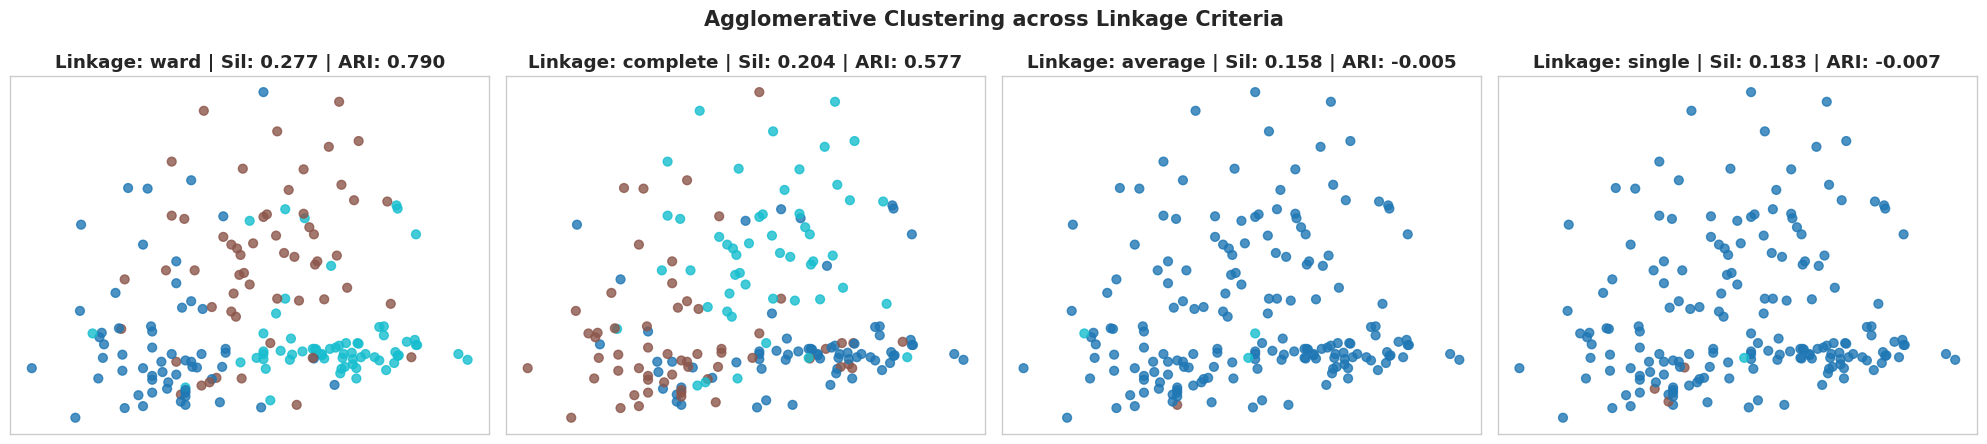

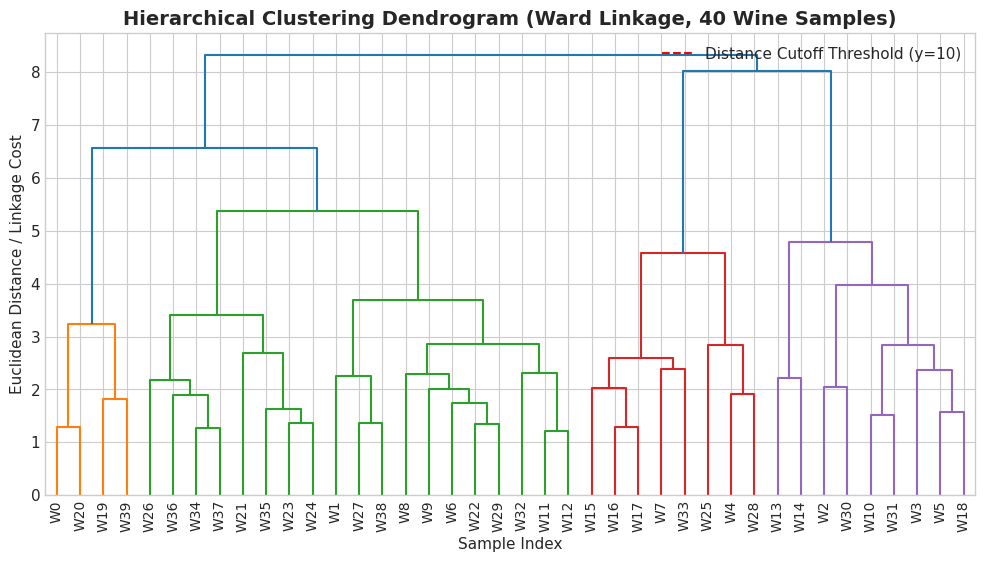

In [12]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Compare Linkage Methods for 3 Clusters
linkage_types = ['ward', 'complete', 'average', 'single']
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))

for i, link in enumerate(linkage_types):
    agg = AgglomerativeClustering(n_clusters=3, linkage=link)
    labels = agg.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    ari = adjusted_rand_score(y, labels)
    
    ax = axes[i]
    scatter = ax.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, cmap='tab10', s=40, alpha=0.8)
    title_str = f"Linkage: {link} | Sil: {sil:.3f} | ARI: {ari:.3f}"
    ax.set_title(title_str, fontweight='bold')
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle("Agglomerative Clustering across Linkage Criteria", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Generate and display Dendrogram using Scipy linkage
plt.figure(figsize=(12, 6))
Z = linkage(X_scaled[:40], method='ward') # First 40 samples for clarity
dendrogram(Z, labels=[f"W{i}" for i in range(40)], leaf_rotation=90, leaf_font_size=10)
plt.axhline(y=10, color='r', linestyle='--', label='Distance Cutoff Threshold (y=10)')
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage, 40 Wine Samples)', fontsize=14, fontweight='bold')
plt.xlabel('Sample Index')
plt.ylabel('Euclidean Distance / Linkage Cost')
plt.legend()
plt.show()
